# Detecting spots with Spotiflow

Adapted from the [Spotiflow inference example](https://github.com/weigertlab/spotiflow/blob/main/examples/2_inference.ipynb).

StarDist and Cellpose gave us the outline of the nuclei. For the repair foci in the other
channel we do not need an outline: they are small and round, and we only want to know
where they are and how many of them are there.

[Spotiflow](https://github.com/weigertlab/spotiflow) predicts one coordinate per spot
instead of a mask. When two spots are close together it can detect them as two spots.

In this notebook we detect the foci, combine them with the nuclei from the previous
notebook, and count foci per nucleus in all four images.

## Libraries

In [1]:
# Plotting libraries
import matplotlib.pyplot as plt
import tifffile as tiff
import numpy as np
import pandas as pd

# We import the spotiflow library
from spotiflow.model import Spotiflow


/var/home/maartenpaul/miniforge3/envs/2026_deep_learning/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Segmenting lysosomes in HeLa cells

Before we go to the repair foci, we try Spotiflow on an image we already know: the HeLa
cells from the Cellpose notebook. The first channel shows lysosomes, which look like small
bright dots in the cytoplasm.

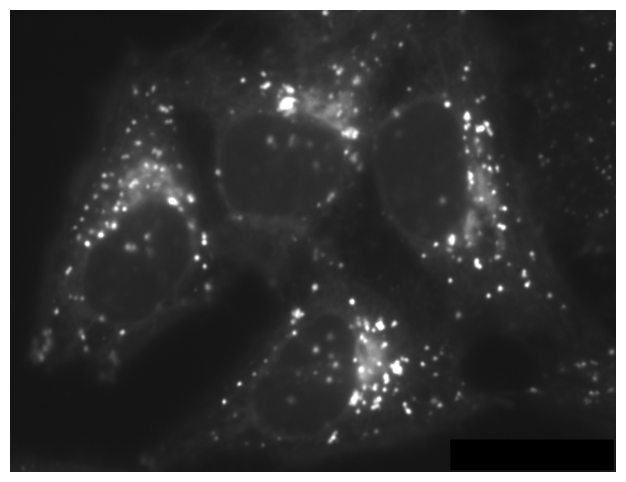

In [2]:
hela = tiff.imread("data/hela_cells.tif")
img_lyso = hela[:, :, 0]

_ = plt.figure(figsize=(8, 6))
_ = plt.imshow(img_lyso, cmap="gray", vmax=np.percentile(img_lyso, 99.8))
_ = plt.axis("off")

Spotiflow has several pretrained models; `general` is the one to start with.
`predict()` returns the spot coordinates as (y, x) pairs, plus some details we do not
need here.

In [3]:
model_spots = Spotiflow.from_pretrained("general")

points_lyso, details = model_spots.predict(img_lyso)

print(f"found {len(points_lyso)} spots")
print(points_lyso[:5])

INFO:spotiflow.model.spotiflow:Loading pretrained model: general
INFO:spotiflow.model.spotiflow:Will use device: cpu
INFO:spotiflow.model.spotiflow:Predicting with prob_thresh = [0.49999999999999994], min_distance = 1
INFO:spotiflow.model.spotiflow:Peak detection mode: fast
INFO:spotiflow.model.spotiflow:Image shape (512, 672)
INFO:spotiflow.model.spotiflow:Predicting with (1, 1) tiles
INFO:spotiflow.model.spotiflow:Normalizing...
INFO:spotiflow.model.spotiflow:Padding to shape (512, 672, 1)
INFO:spotiflow.model.spotiflow:Found 317 spots
found 317 spots
[[481.62335059 279.910313  ]
 [480.03798322 261.92595756]
 [477.06102252 354.63298368]
 [474.25396052 297.89784578]
 [474.01694293 228.01091557]]


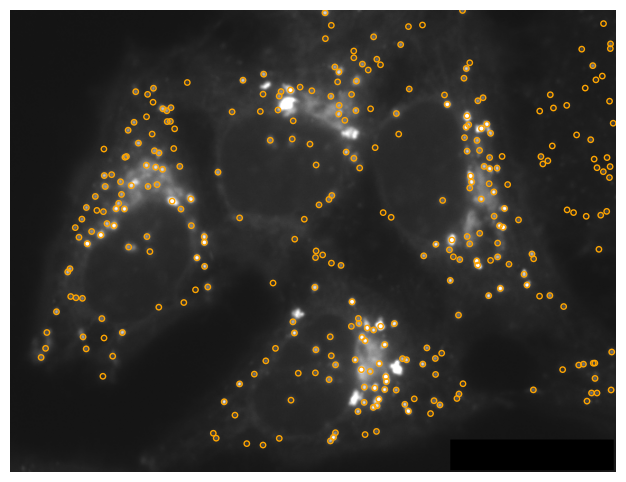

In [4]:
_ = plt.figure(figsize=(8, 6))
_ = plt.imshow(img_lyso, cmap="gray", vmax=np.percentile(img_lyso, 99.8))
_ = plt.scatter(points_lyso[:, 1], points_lyso[:, 0], s=15, facecolors="none", edgecolors="orange")
_ = plt.axis("off")

Zoom in on one cell to check the detections.

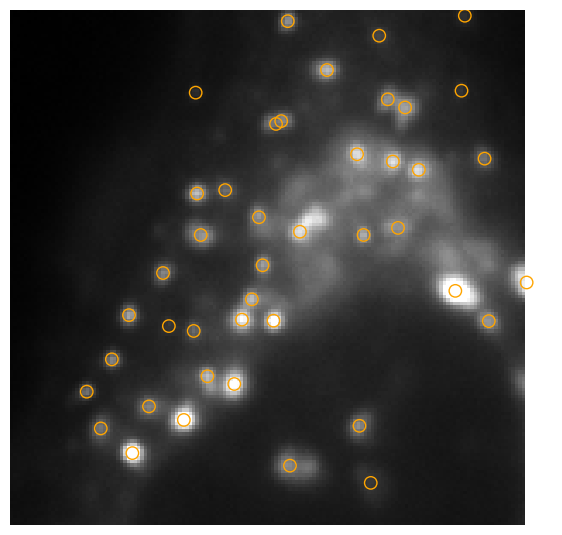

In [5]:
# Take a 150 x 150 pixel crop
y0, x0, size = 130, 50, 150
crop = img_lyso[y0:y0 + size, x0:x0 + size]

# Keep the spots that fall inside the crop
in_crop = ((points_lyso[:, 0] > y0) & (points_lyso[:, 0] < y0 + size)
           & (points_lyso[:, 1] > x0) & (points_lyso[:, 1] < x0 + size))
p = points_lyso[in_crop]

_ = plt.figure(figsize=(7, 7))
_ = plt.imshow(crop, cmap="gray", vmax=np.percentile(img_lyso, 99.8))
_ = plt.scatter(p[:, 1] - x0, p[:, 0] - y0, s=80, facecolors="none", edgecolors="orange")
_ = plt.axis("off")

Most bright dots are found. Very large, bright blobs are sometimes skipped or get a single
spot: Spotiflow looks for small, round spots of a few pixels wide.

# Detecting the foci

Now the real data. We use the first channel of the irradiated image, the one with the DNA
damage foci. We can reuse the model we already loaded.

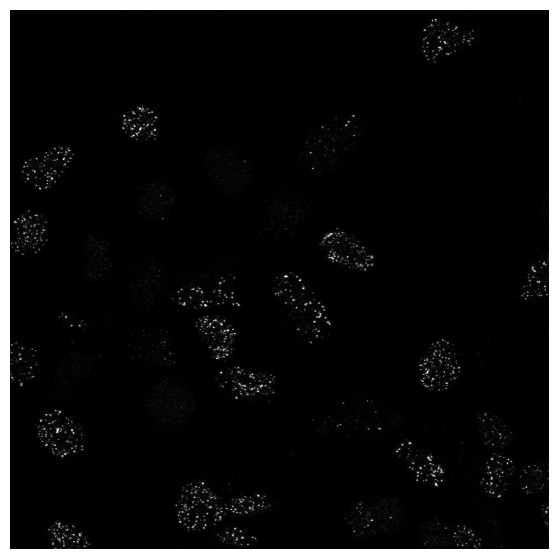

In [7]:
img = tiff.imread("data/MAX_2h_IR_Position002.tif")
img_foci = img[0, :, :]
img_nuclei = img[1, :, :]

_ = plt.figure(figsize=(7, 7))
_ = plt.imshow(img_foci, cmap="gray",vmax=50)
_ = plt.axis("off")

In [8]:
points, details = model_spots.predict(img_foci)

print(f"found {len(points)} spots")

INFO:spotiflow.model.spotiflow:Will use device: cpu
INFO:spotiflow.model.spotiflow:Predicting with prob_thresh = [0.49999999999999994], min_distance = 1
INFO:spotiflow.model.spotiflow:Peak detection mode: fast
INFO:spotiflow.model.spotiflow:Image shape (1024, 1024)
INFO:spotiflow.model.spotiflow:Predicting with (1, 1) tiles
INFO:spotiflow.model.spotiflow:Normalizing...
INFO:spotiflow.model.spotiflow:Padding to shape (1024, 1024, 1)
INFO:spotiflow.model.spotiflow:Found 1709 spots
found 1709 spots


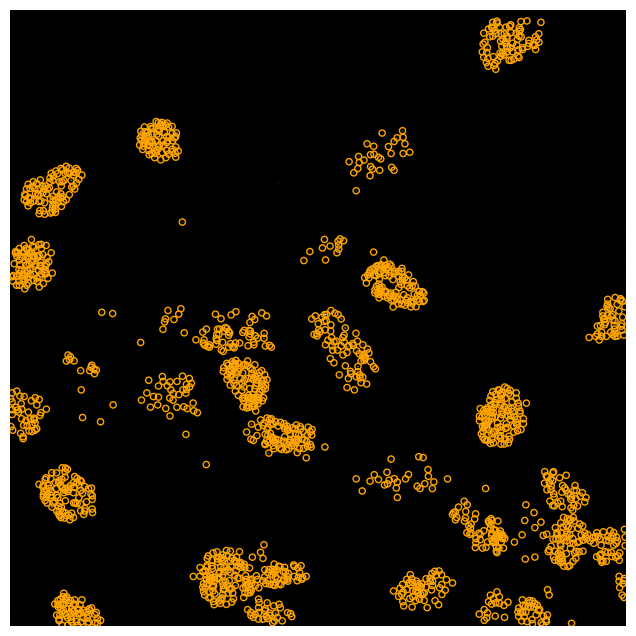

In [9]:
_ = plt.figure(figsize=(8, 8))
_ = plt.imshow(img_foci, cmap="gray")
_ = plt.scatter(points[:, 1], points[:, 0], s=20, facecolors="none", edgecolors="orange")
_ = plt.axis("off")

Hard to judge at this size, so let us zoom in on one nucleus.

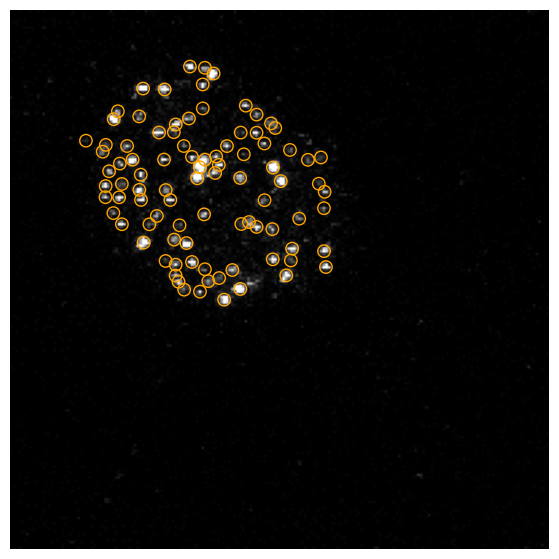

In [10]:
# Take a 200 x 200 pixel crop around one nucleus
y0, x0, size = 740, 20, 200
crop = img_foci[y0:y0 + size, x0:x0 + size]

# Keep the spots that fall inside the crop
in_crop = ((points[:, 0] > y0) & (points[:, 0] < y0 + size)
           & (points[:, 1] > x0) & (points[:, 1] < x0 + size))
points_crop = points[in_crop]

_ = plt.figure(figsize=(7, 7))
_ = plt.imshow(crop, cmap="gray", vmax=np.percentile(img_foci, 99.8))
_ = plt.scatter(points_crop[:, 1] - x0, points_crop[:, 0] - y0, s=80, facecolors="none", edgecolors="orange")
_ = plt.axis("off")

# Which nucleus does each spot belong to?

We segment the nuclei exactly as in the Cellpose notebook. The label image tells us, for
every pixel, which nucleus it belongs to — so we can simply look up the label at the
position of each spot.

In [11]:
from cellpose import models, core

model_nuc = models.CellposeModel(model_type="nuclei")
masks, _, _ = model_nuc.eval(img_nuclei, channels=[0, 0], diameter=80)

print(f"{masks.max()} nuclei")

/var/home/maartenpaul/miniforge3/envs/2026_deep_learning/lib/python3.12/site-packages/torch/jit/_script.py:365: FutureWarning: `torch.jit.script_method` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/var/home/maartenpaul/miniforge3/envs/2026_deep_learning/lib/python3.12/site-packages/cellpose/dynamics.py:760: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/Context.cpp:848.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),


35 nuclei


In [12]:
# The coordinates are floats, so round them to whole pixels
spot_y = np.round(points[:, 0]).astype(int)
spot_x = np.round(points[:, 1]).astype(int)

# Look up the nucleus label under every spot (0 means: not in a nucleus)
spot_label = masks[spot_y, spot_x]

print(f"{np.sum(spot_label > 0)} of {len(points)} spots are inside a nucleus")

1427 of 1709 spots are inside a nucleus


In [13]:
# Count how often each label occurs: that is the number of foci per nucleus
counts = np.bincount(spot_label, minlength=masks.max() + 1)
foci_per_nucleus = counts[1:]   # drop the background (label 0)

print(f"foci per nucleus: {foci_per_nucleus}")
print(f"median: {np.median(foci_per_nucleus):.0f}")

foci per nucleus: [ 71  70   0  60   1   9  80  84   2  43   7  22  13  12  86  27  39 102
   2  66   2  19  39  85  58  63  36  97  40  53   8  17  61  31  22]
median: 39


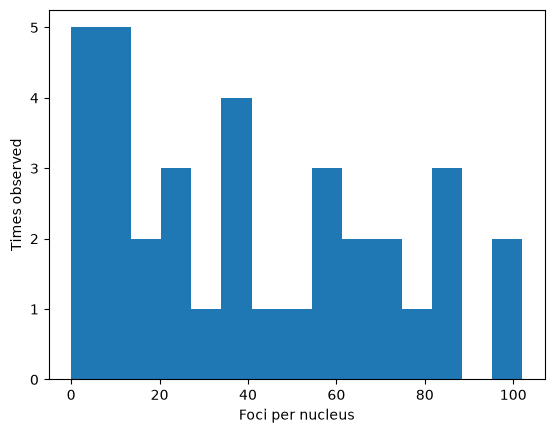

In [14]:
_ = plt.hist(foci_per_nucleus, bins=15)
_ = plt.xlabel("Foci per nucleus")
_ = plt.ylabel("Times observed")

# All four images

We have two irradiated and two control images. Rather than copying the code four times,
we can create a function and call it for each image.

In [18]:
def count_foci_per_nucleus(path):
    """Return the number of foci in each nucleus of a two-channel image."""

    img = tiff.imread(path)

    # Channel 0: the foci
    points, details = model_spots.predict(img[0, :, :], verbose=False)

    # Channel 1: the nuclei
    masks, _, _ = model_nuc.eval(img[1, :, :], channels=[0, 0], diameter=80)

    # Which nucleus is each spot in, and how many spots per nucleus?
    spot_y = np.round(points[:, 0]).astype(int)
    spot_x = np.round(points[:, 1]).astype(int)
    counts = np.bincount(masks[spot_y, spot_x], minlength=masks.max() + 1)

    return counts[1:]

What this function does: It detects the spots and the nuclear mask. Then read for every spot to which nucleus it belongs by checking the value of the label at that location.
Then we return only the counts of the spots inside the nuclei `return counts[:1]`

In [ ]:
files = [
    "data/MAX_2h_control_Position001.tif",
    "data/MAX_2h_control_Position002.tif",
    "data/MAX_2h_IR_Position001.tif",
    "data/MAX_2h_IR_Position002.tif",
]

results = []
for path in files:
    condition = "IR" if "IR" in path else "control"
    for n_foci in count_foci_per_nucleus(path):
        results.append({"file": path, "condition": condition, "foci": n_foci})

results = pd.DataFrame(results)
print(f"{len(results)} nuclei in total")
results.head()

In [ ]:
print(results.groupby("condition")["foci"].describe()[["count", "mean", "50%"]])

# Put the control first, then the irradiated cells
conditions = ["control", "IR"]
data = [results.loc[results["condition"] == c, "foci"] for c in conditions]

_ = plt.boxplot(data, tick_labels=conditions)
_ = plt.ylabel("Foci per nucleus")

The irradiated cells have many more foci per nucleus than the control cells. That is
what we expect: irradiation causes DNA breaks, and the foci are repair proteins
gathering at those breaks.

## Exercise: How many spots does Spotiflow find outside the nuclei?

We saw that some spots are not inside any nucleus.

- How many are there, and where are they in the image?
- Plot them on top of the image and have a look. Are they real foci, and would it be a
  problem to leave them out?

## Exercise: What does the detection threshold change?

`predict()` takes a `prob_thresh` argument: the confidence a spot needs before it is
kept. The default is the value the model was tuned with.

Run the prediction on `img_foci` with `prob_thresh` set to 0.3, 0.5 and 0.7, and plot the
number of detected spots. Look at the crop from earlier for each setting: which spots
appear and disappear?

# Wrapping up

We used three pretrained models without training anything ourselves:

- **StarDist** — nuclei as star-convex polygons
- **Cellpose** — cells and nuclei from predicted flows
- **Spotiflow** — spots as coordinates

In all three, the object size had to match what the model was trained on: `scale` in
StarDist, `diameter` in Cellpose. On day 3 we look at training a model on your own data.